In [27]:
import pandas as pd

In [28]:
df = pd.read_csv('../data/final_panel_data.csv')

Columns with missing values (8): ['brent_oil', 'inflation', 'fx_rate', 'ip', 'stock_index', 'terms_of_trade', 'reserves', 'debt']
Country coverage summary by sparse column:
                countries_with_any_missing  countries_with_complete_coverage
brent_oil                               39                                 2
terms_of_trade                          18                                23
debt                                     7                                34
ip                                       5                                36
stock_index                              3                                38
inflation                                3                                38
reserves                                 3                                38
fx_rate                                  1                                40
Country-column pairs with partial missingness (1%-99%):
isocode         column  percent_missing
    COL    stock_index        57.22222

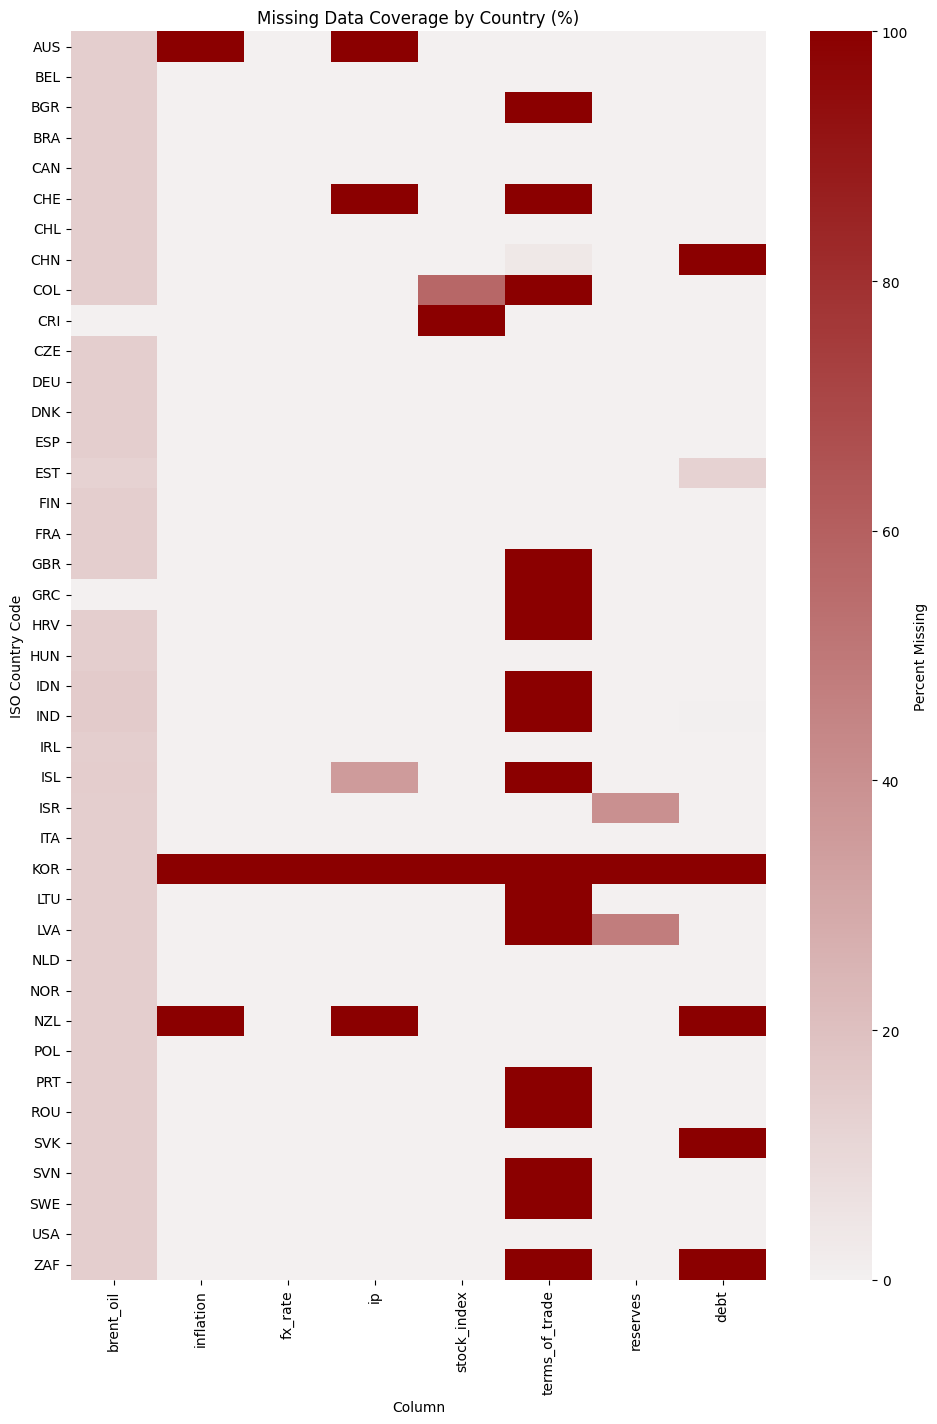

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sparse_cols = df.columns[df.isna().any()].tolist()
print(f"Columns with missing values ({len(sparse_cols)}): {sparse_cols}")

missing_pct_by_country = (
    df.groupby('isocode')[sparse_cols]
    .apply(lambda group: group.isna().mean() * 100)
    .sort_index()
)

country_missing_summary = pd.DataFrame({
    'countries_with_any_missing': (missing_pct_by_country.gt(0)).sum(),
    'countries_with_complete_coverage': (missing_pct_by_country.eq(0)).sum(),
}).sort_values('countries_with_any_missing', ascending=False)

print('Country coverage summary by sparse column:')
print(country_missing_summary)

partial_missingness = (
    missing_pct_by_country.stack()
    .rename('percent_missing')
    .reset_index()
    .query('0 < percent_missing < 100')
    .sort_values(['percent_missing', 'isocode', 'level_1'], ascending=[False, True, True])
    .rename(columns={'level_1': 'column'})
)

print('Country-column pairs with partial missingness (1%-99%):')
if partial_missingness.empty:
    print('None')
else:
    print(partial_missingness.to_string(index=False))

n_countries = len(missing_pct_by_country)
figsize = (max(len(sparse_cols) * 1.2, 6), max(n_countries * 0.35, 3))

plt.figure(figsize=figsize)
sns.heatmap(
    missing_pct_by_country,
    cmap=sns.light_palette('darkred', as_cmap=True),
    vmin=0,
    vmax=100,
    annot=n_countries < 20,
    fmt='.1f',
    cbar_kws={'label': 'Percent Missing'},
)
plt.title('Missing Data Coverage by Country (%)')
plt.xlabel('Column')
plt.ylabel('ISO Country Code')
plt.tight_layout()
plt.show()

In [32]:
df = df.loc[df["isocode"] != "KOR"].copy()

cols_to_drop = df.loc[:, "terms_of_trade":"date"].columns
df = df.drop(columns=cols_to_drop)

print(df.shape)
df.head()


(6933, 32)


,isocode,date,yield_10y,period,Competition and Sports,Health and Education,Military Conflict,Politics,Military Technology,National Development,...,vix,brent_oil,credit_spread,inflation,fx_rate,ip,stock_index,terms_of_trade,reserves,debt
0,AUS,1/1/2010,5.5575,201001,0.061398,0.073588,0.019415,0.019441,0.031388,0.067876,...,24.620001,71.459999,33.675831,NaN,1.096781,NaN,100.00000,1.000000,38864.08,19.242444
1,AUS,2/1/2010,5.4775,201002,0.062448,0.073145,0.020595,0.021634,0.036304,0.063547,...,19.500000,77.589996,34.042908,NaN,1.127445,NaN,92.23358,1.023580,36759.20,19.242444
2,AUS,3/1/2010,5.6200,201003,0.059424,0.075694,0.019563,0.022156,0.035235,0.072683,...,17.590000,82.699997,34.778976,NaN,1.095715,NaN,99.37471,1.059195,34988.19,19.242444
3,AUS,4/1/2010,5.7950,201004,0.055710,0.078934,0.019159,0.021588,0.041275,0.076524,...,22.049999,87.440002,35.447002,NaN,1.079094,NaN,103.29460,1.131496,38017.30,19.423733
4,AUS,5/1/2010,5.4800,201005,0.059780,0.075806,0.016951,0.023082,0.042158,0.076380,...,32.070000,74.019997,33.799465,NaN,1.152476,NaN,88.52134,1.173233,33339.69,19.423733


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional safety check: ensure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

THRESHOLDS = {
    "raw": 0.5,       # percentage-point change in yield
    "pct": 20.0,      # percent change
    "var_q": 0.90,    # quantile used to set spike_var threshold
    "dev_12m": 0.75,  # percentage points above trailing 12m mean
    "dev_6m": 0.75,   # percentage points above trailing 6m mean
    "dev_3m": 0.75,   # percentage points above trailing 3m mean
}


In [40]:
g = df.groupby("isocode", group_keys=False)

# 1. Month-over-month changes
df["delta_raw"] = g["yield_10y"].diff()
df["delta_pct"] = g["yield_10y"].pct_change() * 100

# 2. Trailing 12-month rolling variance of current yield
df["rolling_var_12"] = (
    g["yield_10y"]
    .transform(lambda s: s.rolling(window=12, min_periods=6).var())
)

# 3. Deviations from trailing means, excluding current month via shift(1)
rolling_mean_12 = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)
rolling_mean_6 = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=6, min_periods=3).mean()
)
rolling_mean_3 = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=2).mean()
)

df["dev_from_mean_12m"] = df["yield_10y"] - rolling_mean_12
df["dev_from_mean_6m"] = df["yield_10y"] - rolling_mean_6
df["dev_from_mean_3m"] = df["yield_10y"] - rolling_mean_3

# Default variance threshold from observed distribution
threshold_var = df["rolling_var_12"].quantile(THRESHOLDS["var_q"])
print(f"Computed variance threshold (q={THRESHOLDS['var_q']:.2f}): {threshold_var:.4f}")


Computed variance threshold (q=0.90): 0.5643


In [41]:
# Spike flags
df["spike_raw"] = np.where(
    df["delta_raw"].notna(),
    df["delta_raw"] > THRESHOLDS["raw"],
    np.nan,
)

df["spike_pct"] = np.where(
    df["delta_pct"].notna(),
    df["delta_pct"] > THRESHOLDS["pct"],
    np.nan,
)

df["spike_var"] = np.where(
    df["rolling_var_12"].notna(),
    df["rolling_var_12"] > threshold_var,
    np.nan,
)

df["spike_dev_12m"] = np.where(
    df["dev_from_mean_12m"].notna(),
    df["dev_from_mean_12m"] > THRESHOLDS["dev_12m"],
    np.nan,
)

df["spike_dev_6m"] = np.where(
    df["dev_from_mean_6m"].notna(),
    df["dev_from_mean_6m"] > THRESHOLDS["dev_6m"],
    np.nan,
)

df["spike_dev_3m"] = np.where(
    df["dev_from_mean_3m"].notna(),
    df["dev_from_mean_3m"] > THRESHOLDS["dev_3m"],
    np.nan,
)


In [42]:
def make_onset(spike_series):
    prev_spike = spike_series.shift(1)
    onset = (spike_series == True) & (prev_spike.fillna(False) != True)
    onset = onset.astype("object")
    onset[spike_series.isna()] = np.nan
    return onset

df["onset_raw"] = g["spike_raw"].transform(make_onset)
df["onset_pct"] = g["spike_pct"].transform(make_onset)
df["onset_var"] = g["spike_var"].transform(make_onset)
df["onset_dev_12m"] = g["spike_dev_12m"].transform(make_onset)
df["onset_dev_6m"] = g["spike_dev_6m"].transform(make_onset)
df["onset_dev_3m"] = g["spike_dev_3m"].transform(make_onset)


       target  total_onset_events  onset_rate_pct  countries_with_at_least_one_onset  median_episodes_per_country
    onset_pct                 528        7.659945                                 39                         15.0
    onset_raw                 184        2.669375                                 37                          3.0
 onset_dev_6m                 136        1.996184                                 38                          2.5
 onset_dev_3m                 128        1.867795                                 35                          3.0
onset_dev_12m                 121        1.807859                                 39                          3.0
    onset_var                  74        1.099064                                 33                          2.0


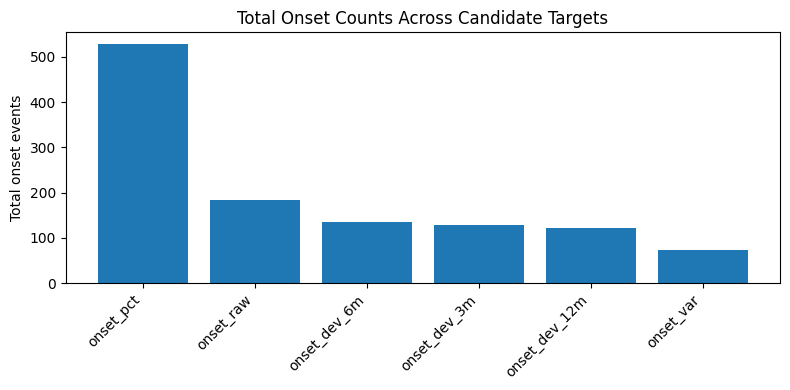

In [38]:
onset_cols = [
    "onset_raw",
    "onset_pct",
    "onset_var",
    "onset_dev_12m",
    "onset_dev_6m",
    "onset_dev_3m",
]

summary_rows = []

for col in onset_cols:
    valid = df[col].dropna()
    total_onsets = int(valid.sum()) if len(valid) else 0
    onset_rate = float(valid.mean() * 100) if len(valid) else np.nan

    by_country = (
        df.loc[df[col].notna()]
        .groupby("isocode")[col]
        .sum()
    )

    countries_with_onset = int((by_country > 0).sum()) if len(by_country) else 0
    median_episodes = (
        float(by_country[by_country > 0].median())
        if (by_country > 0).any()
        else np.nan
    )

    summary_rows.append({
        "target": col,
        "total_onset_events": total_onsets,
        "onset_rate_pct": onset_rate,
        "countries_with_at_least_one_onset": countries_with_onset,
        "median_episodes_per_country": median_episodes,
    })

summary = pd.DataFrame(summary_rows).sort_values("total_onset_events", ascending=False)

print(summary.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(summary["target"], summary["total_onset_events"])
plt.title("Total Onset Counts Across Candidate Targets")
plt.ylabel("Total onset events")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


             rule  threshold  total_onsets  onset_rate_pct  countries_with_onset  median_episodes_per_country
dev_from_mean_12m       0.25           276        4.123711                    40                          7.0
dev_from_mean_12m       0.50           183        2.734200                    40                          4.0
dev_from_mean_12m       0.75           121        1.807859                    39                          3.0
dev_from_mean_12m       1.00           100        1.494098                    38                          2.0
dev_from_mean_12m       1.25            85        1.269984                    37                          2.0
dev_from_mean_12m       1.50            71        1.060810                    34                          2.0
        delta_raw       0.10          1004       14.565501                    40                         25.0
        delta_raw       0.25           505        7.326273                    40                         12.0
        de

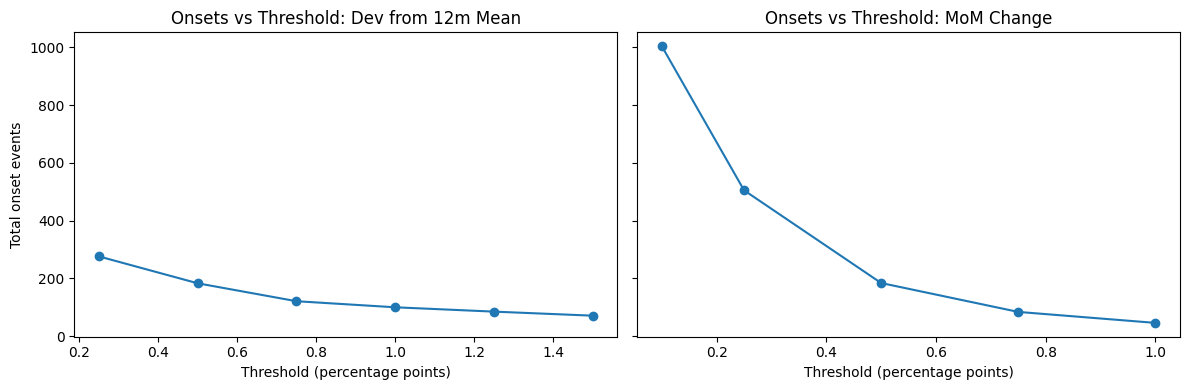

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g = df.groupby("isocode", group_keys=False)

# Recompute the two underlying signals cleanly
df["delta_raw"] = g["yield_10y"].diff()

trailing_mean_12m = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)
df["dev_from_mean_12m"] = df["yield_10y"] - trailing_mean_12m

def make_onset_from_signal(signal, threshold):
    spike = pd.Series(np.where(signal.notna(), signal > threshold, np.nan), index=signal.index)
    
    def onset_with_nan(s):
        prev = s.shift(1)
        onset = (s == True) & (prev.fillna(False) != True)
        onset = onset.astype("object")
        onset[s.isna()] = np.nan
        return onset

    onset = spike.groupby(df["isocode"], group_keys=False).transform(onset_with_nan)
    return onset

# Threshold grids to tune
dev_thresholds = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50]   # percentage points above trailing mean
mom_thresholds = [0.10, 0.25, 0.50, 0.75, 1.00]         # percentage-point monthly increase

results = []

for th in dev_thresholds:
    onset = make_onset_from_signal(df["dev_from_mean_12m"], th)
    valid = onset.dropna()
    by_country = df.loc[onset.notna()].groupby("isocode")[onset.name if onset.name else "yield_10y"].size()
    
    country_events = onset.groupby(df["isocode"]).apply(lambda s: s.dropna().sum())
    countries_with_event = int((country_events > 0).sum())
    median_events = float(country_events[country_events > 0].median()) if (country_events > 0).any() else np.nan

    results.append({
        "rule": "dev_from_mean_12m",
        "threshold": th,
        "total_onsets": int(valid.sum()) if len(valid) else 0,
        "onset_rate_pct": float(valid.mean() * 100) if len(valid) else np.nan,
        "countries_with_onset": countries_with_event,
        "median_episodes_per_country": median_events,
    })

for th in mom_thresholds:
    onset = make_onset_from_signal(df["delta_raw"], th)
    valid = onset.dropna()

    country_events = onset.groupby(df["isocode"]).apply(lambda s: s.dropna().sum())
    countries_with_event = int((country_events > 0).sum())
    median_events = float(country_events[country_events > 0].median()) if (country_events > 0).any() else np.nan

    results.append({
        "rule": "delta_raw",
        "threshold": th,
        "total_onsets": int(valid.sum()) if len(valid) else 0,
        "onset_rate_pct": float(valid.mean() * 100) if len(valid) else np.nan,
        "countries_with_onset": countries_with_event,
        "median_episodes_per_country": median_events,
    })

tuning_summary = pd.DataFrame(results)
print(tuning_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

dev_plot = tuning_summary[tuning_summary["rule"] == "dev_from_mean_12m"]
mom_plot = tuning_summary[tuning_summary["rule"] == "delta_raw"]

axes[0].plot(dev_plot["threshold"], dev_plot["total_onsets"], marker="o")
axes[0].set_title("Onsets vs Threshold: Dev from 12m Mean")
axes[0].set_xlabel("Threshold (percentage points)")
axes[0].set_ylabel("Total onset events")

axes[1].plot(mom_plot["threshold"], mom_plot["total_onsets"], marker="o")
axes[1].set_title("Onsets vs Threshold: MoM Change")
axes[1].set_xlabel("Threshold (percentage points)")

plt.tight_layout()
plt.show()


In [45]:
import numpy as np
import pandas as pd

# Adjustable threshold in percentage points
DEV_12M_THRESHOLD = 0.25

g = df.groupby("isocode", group_keys=False)

# Recompute trailing 12m mean excluding the current month
trailing_mean_12m = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)

df["dev_from_mean_12m"] = df["yield_10y"] - trailing_mean_12m

# Incidence: 1 whenever the country is above the threshold
df["incidence_dev_12m"] = np.where(
    df["dev_from_mean_12m"].notna(),
    df["dev_from_mean_12m"] > DEV_12M_THRESHOLD,
    np.nan,
)

# Onset: 1 only when it switches from not-spiking to spiking within country
def make_onset(spike_series):
    prev_spike = spike_series.shift(1)
    onset = (spike_series == True) & (prev_spike.fillna(False) != True)
    onset = onset.astype("object")
    onset[spike_series.isna()] = np.nan
    return onset

df["onset_dev_12m"] = g["incidence_dev_12m"].transform(make_onset)

print(f"Using DEV_12M_THRESHOLD = {DEV_12M_THRESHOLD:.2f} percentage points")


Using DEV_12M_THRESHOLD = 0.25 percentage points


In [46]:
# Change this list to whatever countries you want to inspect
sample_countries = df["isocode"].dropna().unique()[:3].tolist()

cols_to_show = [
    "isocode",
    "date",
    "yield_10y",
    "dev_from_mean_12m",
    "incidence_dev_12m",
    "onset_dev_12m",
]

for country in sample_countries:
    print(f"\n===== {country} =====")
    display(
        df.loc[df["isocode"] == country, cols_to_show]
        .sort_values("date")
        .reset_index(drop=True)
        .tail(24)
    )



===== AUS =====


,isocode,date,yield_10y,dev_from_mean_12m,incidence_dev_12m,onset_dev_12m
156,AUS,2023-01-01,3.604,0.407500,1.0,False
157,AUS,2023-02-01,3.702,0.362500,1.0,False
158,AUS,2023-03-01,3.468,-0.004083,0.0,False
159,AUS,2023-04-01,3.343,-0.209750,0.0,False
160,AUS,2023-05-01,3.500,-0.080667,0.0,False
161,AUS,2023-06-01,3.916,0.325417,1.0,True
162,AUS,2023-07-01,4.036,0.433000,1.0,False
163,AUS,2023-08-01,4.128,0.474417,1.0,False
164,AUS,2023-09-01,4.211,0.493500,1.0,False
165,AUS,2023-10-01,4.633,0.876833,1.0,False



===== BEL =====


,isocode,date,yield_10y,dev_from_mean_12m,incidence_dev_12m,onset_dev_12m
156,BEL,2023-01-01,2.79,1.056667,1.0,False
157,BEL,2023-02-01,2.96,1.015833,1.0,False
158,BEL,2023-03-01,3.04,0.898333,1.0,False
159,BEL,2023-04-01,3.05,0.720833,1.0,False
160,BEL,2023-05-01,3.04,0.565000,1.0,False
161,BEL,2023-06-01,3.05,0.453333,1.0,False
162,BEL,2023-07-01,3.14,0.466667,1.0,False
163,BEL,2023-08-01,3.22,0.435000,1.0,False
164,BEL,2023-09-01,3.32,0.409167,1.0,False
165,BEL,2023-10-01,3.52,0.536667,1.0,False



===== BGR =====


,isocode,date,yield_10y,dev_from_mean_12m,incidence_dev_12m,onset_dev_12m
156,BGR,2023-01-01,1.85,0.318333,1.0,False
157,BGR,2023-02-01,2.73,1.091667,1.0,False
158,BGR,2023-03-01,4.21,2.395000,1.0,False
159,BGR,2023-04-01,4.03,1.955000,1.0,False
160,BGR,2023-05-01,4.03,1.754167,1.0,False
161,BGR,2023-06-01,4.03,1.553333,1.0,False
162,BGR,2023-07-01,4.03,1.365000,1.0,False
163,BGR,2023-08-01,4.03,1.183333,1.0,False
164,BGR,2023-09-01,4.03,1.001667,1.0,False
165,BGR,2023-10-01,4.03,0.820000,1.0,False


Threshold-level summary:


,threshold,incidence_total_months,incidence_rate_pct,onset_total_events,onset_rate_pct,countries_with_incidence,countries_with_onset,country_incidence_balance_mean_pct,country_incidence_balance_min_pct,country_incidence_balance_max_pct,country_incidence_balance_var,country_onset_balance_mean_pct,country_onset_balance_min_pct,country_onset_balance_max_pct,country_onset_balance_var
0,0.2,1875,28.014343,313,4.676528,40,40,28.269303,7.471264,42.857143,0.004602,4.612572,1.149425,7.333333,0.000265
1,0.3,1552,23.188406,254,3.795010,40,40,23.497471,6.896552,40.816327,0.004573,3.768156,1.149425,7.333333,0.000214
2,0.4,1298,19.393396,219,3.272075,40,40,19.753379,6.349206,40.816327,0.004841,3.262903,1.149425,7.471264,0.000195
3,0.5,1033,15.434036,183,2.734200,40,40,15.814906,3.968254,36.734694,0.004932,2.735451,1.149425,7.471264,0.000178
4,0.6,863,12.894068,158,2.360675,39,39,13.220209,0.000000,32.653061,0.004581,2.373228,0.000000,6.164384,0.000209
5,0.7,746,11.145973,129,1.927387,39,39,11.411537,0.000000,28.571429,0.004153,1.939777,0.000000,5.172414,0.000159
6,0.8,633,9.457642,113,1.688331,39,39,9.755480,0.000000,28.571429,0.003903,1.694840,0.000000,5.172414,0.000168



Country-threshold balance summary (first 20 rows):


,isocode,threshold,incidence_balance_pct,onset_balance_pct
0,AUS,0.2,28.160920,6.896552
1,BEL,0.2,26.436782,5.172414
2,BGR,0.2,18.390805,2.873563
3,BRA,0.2,31.034483,2.298851
4,CAN,0.2,29.310345,6.896552
5,CHE,0.2,20.689655,6.321839
6,CHL,0.2,20.114943,2.873563
7,CHN,0.2,15.873016,1.587302
8,COL,0.2,35.632184,6.321839
9,CRI,0.2,40.000000,4.516129


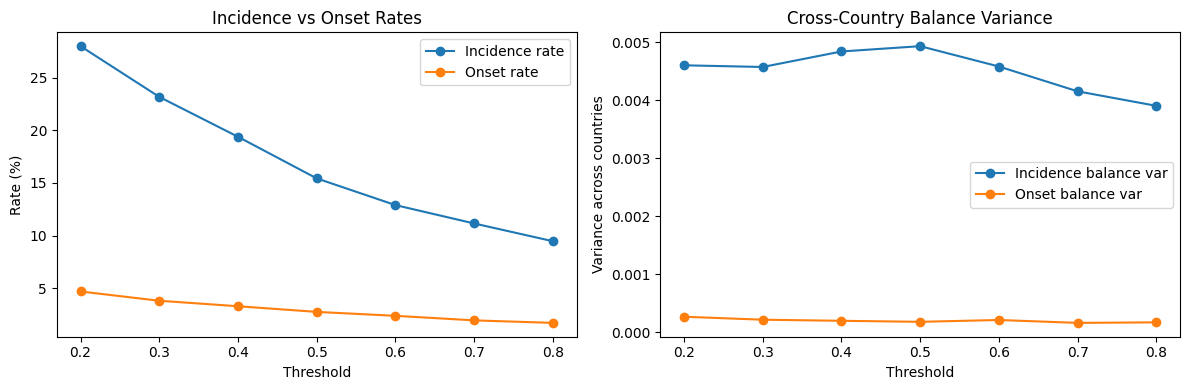

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Threshold grid to search
threshold_grid = np.round(np.arange(0.2, 0.81, 0.1), 2)

g = df.groupby("isocode", group_keys=False)

# Recompute dev_from_mean_12m cleanly
trailing_mean_12m = g["yield_10y"].transform(
    lambda s: s.shift(1).rolling(window=12, min_periods=6).mean()
)
df["dev_from_mean_12m"] = df["yield_10y"] - trailing_mean_12m

summary_rows = []
country_balance_rows = []

for th in threshold_grid:
    incidence = pd.Series(
        np.where(
            df["dev_from_mean_12m"].notna(),
            df["dev_from_mean_12m"] > th,
            np.nan,
        ),
        index=df.index,
        name=f"incidence_dev_12m_{th:.2f}",
    )

    def make_onset(spike_series):
        prev_spike = spike_series.shift(1)
        onset = (spike_series == True) & (prev_spike.fillna(False) != True)
        onset = onset.astype("object")
        onset[spike_series.isna()] = np.nan
        return onset

    onset = incidence.groupby(df["isocode"], group_keys=False).transform(make_onset)
    onset.name = f"onset_dev_12m_{th:.2f}"

    incidence_valid = incidence.dropna()
    onset_valid = onset.dropna()

    incidence_by_country = (
        pd.DataFrame({"isocode": df["isocode"], "incidence": incidence})
        .dropna(subset=["incidence"])
        .groupby("isocode")["incidence"]
        .mean()
    )

    onset_by_country = (
        pd.DataFrame({"isocode": df["isocode"], "onset": onset})
        .dropna(subset=["onset"])
        .groupby("isocode")["onset"]
        .mean()
    )

    summary_rows.append({
        "threshold": th,
        "incidence_total_months": int(incidence_valid.sum()) if len(incidence_valid) else 0,
        "incidence_rate_pct": float(incidence_valid.mean() * 100) if len(incidence_valid) else np.nan,
        "onset_total_events": int(onset_valid.sum()) if len(onset_valid) else 0,
        "onset_rate_pct": float(onset_valid.mean() * 100) if len(onset_valid) else np.nan,
        "countries_with_incidence": int((incidence_by_country > 0).sum()) if len(incidence_by_country) else 0,
        "countries_with_onset": int((onset_by_country > 0).sum()) if len(onset_by_country) else 0,
        "country_incidence_balance_mean_pct": float(incidence_by_country.mean() * 100) if len(incidence_by_country) else np.nan,
        "country_incidence_balance_min_pct": float(incidence_by_country.min() * 100) if len(incidence_by_country) else np.nan,
        "country_incidence_balance_max_pct": float(incidence_by_country.max() * 100) if len(incidence_by_country) else np.nan,
        "country_incidence_balance_var": float(incidence_by_country.var()) if len(incidence_by_country) else np.nan,
        "country_onset_balance_mean_pct": float(onset_by_country.mean() * 100) if len(onset_by_country) else np.nan,
        "country_onset_balance_min_pct": float(onset_by_country.min() * 100) if len(onset_by_country) else np.nan,
        "country_onset_balance_max_pct": float(onset_by_country.max() * 100) if len(onset_by_country) else np.nan,
        "country_onset_balance_var": float(onset_by_country.var()) if len(onset_by_country) else np.nan,
    })

    tmp_country = pd.DataFrame({
        "isocode": incidence_by_country.index,
        "threshold": th,
        "incidence_balance_pct": incidence_by_country.values * 100,
        "onset_balance_pct": onset_by_country.reindex(incidence_by_country.index).values * 100,
    })
    country_balance_rows.append(tmp_country)

threshold_summary = pd.DataFrame(summary_rows).sort_values("threshold")
country_balance_summary = pd.concat(country_balance_rows, ignore_index=True)

print("Threshold-level summary:")
display(threshold_summary)

print("\nCountry-threshold balance summary (first 20 rows):")
display(country_balance_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(threshold_summary["threshold"], threshold_summary["incidence_rate_pct"], marker="o", label="Incidence rate")
axes[0].plot(threshold_summary["threshold"], threshold_summary["onset_rate_pct"], marker="o", label="Onset rate")
axes[0].set_title("Incidence vs Onset Rates")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Rate (%)")
axes[0].legend()

axes[1].plot(threshold_summary["threshold"], threshold_summary["country_incidence_balance_var"], marker="o", label="Incidence balance var")
axes[1].plot(threshold_summary["threshold"], threshold_summary["country_onset_balance_var"], marker="o", label="Onset balance var")
axes[1].set_title("Cross-Country Balance Variance")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Variance across countries")
axes[1].legend()

plt.tight_layout()
plt.show()
